# 06 - Age-conditioned survival scoring: what happens next from today?

A stakeholder does not usually ask:

> What was this customer's probability of surviving the first 90 days after signup?

They ask:

> Given this customer is still here today, what is the probability they are still here 30, 90, or 180 days from now?

Those are different questions.

This notebook teaches the difference using the subscription-retention data from notebook 05. Think of the **Aegis kernel** as the scoring layer behind a client page: every curve, horizon, risk tier, and recommendation must answer the same planning question:

> **Given the customer is active as of the scoring date, what happens next?**

We will deliberately fit a normal signup-time Cox model first, then repair its predictions using age-conditioned survival scoring.

## The one formula that prevents the mistake

A survival model trained from signup gives a curve:

\[
S(t \mid x) = P(T > t \mid x)
\]

where `t = 0` means signup.

If a customer has already survived to age `a` days as of today, the forward probability for the next `Δ` days is not `S(Δ | x)`. It is:

\[
P(T > a + \Delta \mid T > a, x) = \frac{S(a + \Delta \mid x)}{S(a \mid x)}
\]

And the forward churn risk is:

\[
P(a < T \le a + \Delta \mid T > a, x) = 1 - \frac{S(a + \Delta \mid x)}{S(a \mid x)}
\]

Plain English:

- `S(90)` asks, "would this customer survive the first 90 days after signup?"
- `S(age + 90) / S(age)` asks, "given they already made it to today, will they survive 90 more days?"

That second question is the client-facing planning answer.

Reference points worth knowing: conditional survival is commonly written as `S(s + t) / S(s)` in biostatistics, and landmarking is the broader framework for dynamic prediction among people still at risk at a chosen prediction time. See the [conditional survival formula](https://www.pauldickman.com/software/stata/conditional-survival/), the [conditional survival review](https://pmc.ncbi.nlm.nih.gov/articles/PMC6195126/), and [dynamic prediction by landmarking](https://pmc.ncbi.nlm.nih.gov/articles/PMC2798037/).

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from lifelines import CoxPHFitter, KaplanMeierFitter

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


def find_intro_dir() -> Path:
    """Make the notebook runnable from the repo root or from this folder."""
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd


INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
DATA_PATH = DATA_DIR / "subscription_retention_project.csv"

print(f"Using data file: {DATA_PATH}")

Using data file: /Users/josephazar/Desktop/WORK/GITHUB/Survival Analysis/survival-analysis-intro/data/subscription_retention_project.csv


## 1. Load the synthetic subscription cohort

This dataset is synthetic. Each row is one customer.

Important columns:

- `signup_date`: when the customer's clock starts.
- `duration_days_since_signup`: how long we observed them from signup until churn or censoring.
- `churn_observed`: `1` if churn was observed, `0` if the customer was censored.
- first-30-day behavior columns: features we would know after onboarding, such as logins, feature events, support tickets, and payment failures.

We will score customers as of **2025-01-01**. That date is inside the study window, so we can teach the scoring problem as if we are standing there with partial history.

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["signup_date", "study_end_date"])
STUDY_END = raw["study_end_date"].iloc[0]
TODAY = pd.Timestamp("2025-01-01")
HORIZONS = np.array([30, 90, 180])

summary = pd.DataFrame(
    {
        "value": [
            len(raw),
            raw["signup_date"].min().date(),
            raw["signup_date"].max().date(),
            STUDY_END.date(),
            TODAY.date(),
            raw["churn_observed"].mean(),
            raw["duration_days_since_signup"].median(),
        ]
    },
    index=[
        "customers",
        "first signup",
        "last signup",
        "study end",
        "scoring date",
        "observed churn rate",
        "median observed duration",
    ],
)

display(summary)
display(raw.head())

,value
customers,2600
first signup,2024-01-01
last signup,2024-12-30
study end,2025-06-30
scoring date,2025-01-01
observed churn rate,0.512692
median observed duration,239.5


,customer_id,signup_date,plan,acquisition_channel,region,company_size,annual_contract,first_30_logins,key_feature_events_30,support_tickets_30,payment_failures_30,onboarding_score_30,duration_days_since_signup,churn_observed,study_end_date
0,R00001,2024-09-08,Starter,Paid Search,North America,11-50,0,8,6,2,0,65.9,295,0,2025-06-30
1,R00002,2024-11-06,Starter,Paid Search,APAC,1-10,0,10,1,1,0,62.9,233,1,2025-06-30
2,R00003,2024-03-27,Starter,Paid Search,APAC,51-200,0,3,3,0,0,51.6,144,1,2025-06-30
3,R00004,2024-02-08,Growth,Partner,LATAM,1-10,0,8,4,0,0,58.0,508,0,2025-06-30
4,R00005,2024-12-01,Starter,Organic,North America,11-50,0,9,3,1,1,28.2,211,0,2025-06-30


## 2. Fit a signup-time Cox model

For this lesson we intentionally fit a model whose time origin is **signup**.

That is not wrong by itself. Many survival models are trained this way. The mistake happens later, when someone takes `S(30)`, `S(90)`, or `S(180)` from that curve and describes those values as "next 30 / 90 / 180 days" for a customer who is already months old.

Because our features are measured during the first 30 days, we keep customers who survived beyond day 30. That avoids using onboarding features for customers who did not have a full onboarding window.

In [3]:
continuous_features = [
    "annual_contract",
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
]

categorical_features = ["plan", "acquisition_channel", "region", "company_size"]
feature_cols = continuous_features + categorical_features

model_raw = raw[raw["duration_days_since_signup"] > 30].copy()


def make_design_matrix(df: pd.DataFrame) -> pd.DataFrame:
    return pd.get_dummies(
        df[feature_cols],
        columns=categorical_features,
        drop_first=True,
        dtype=float,
    )


X_train = make_design_matrix(model_raw)
cox_train = pd.concat(
    [
        X_train.reset_index(drop=True),
        model_raw[["duration_days_since_signup", "churn_observed"]].reset_index(drop=True),
    ],
    axis=1,
)

cph = CoxPHFitter(penalizer=0.03)
cph.fit(
    cox_train,
    duration_col="duration_days_since_signup",
    event_col="churn_observed",
)

print(f"Training rows after day-30 eligibility filter: {len(cox_train):,}")
print(f"Cox concordance on the training cohort: {cph.concordance_index_:.3f}")

top_effects = cph.summary[["coef", "exp(coef)", "p"]].sort_values("p").head(8)
display(top_effects.style.format({"coef": "{:.3f}", "exp(coef)": "{:.3f}", "p": "{:.2e}"}))

Training rows after day-30 eligibility filter: 2,464
Cox concordance on the training cohort: 0.730


,coef,exp(coef),p
covariate,,,
plan_Starter,0.482,1.619,2.02e-11
support_tickets_30,0.170,1.186,4.69e-10
onboarding_score_30,-0.016,0.984,1.16e-08
annual_contract,-0.517,0.597,1.87e-08
payment_failures_30,0.406,1.501,1.27e-07
acquisition_channel_Paid Search,0.263,1.300,8.05e-05
first_30_logins,-0.045,0.956,1.96e-04
key_feature_events_30,-0.069,0.933,2.50e-04


## 3. Build the alive-today scoring cohort

Now we switch from model training to scoring.

A customer is eligible for today's score if:

- they signed up at least 30 days before today, so onboarding features are known;
- their observed duration is greater than their age today, so they were still active at the scoring date.

This is the same conceptual guardrail as a landmark cohort: only score customers who are actually still at risk at the prediction time.

In [4]:
scoring_raw = model_raw.copy()
scoring_raw["age_today"] = (TODAY - scoring_raw["signup_date"]).dt.days

scoring_raw = scoring_raw[
    (scoring_raw["signup_date"] <= TODAY - pd.Timedelta(days=30))
    & (scoring_raw["age_today"] >= 30)
    & (scoring_raw["duration_days_since_signup"] > scoring_raw["age_today"])
].copy()

X_score = make_design_matrix(scoring_raw).reindex(columns=X_train.columns, fill_value=0)
scoring_raw["relative_hazard"] = cph.predict_partial_hazard(X_score).values
scoring_raw["risk_percentile"] = scoring_raw["relative_hazard"].rank(pct=True)

age_profile = scoring_raw["age_today"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("age_today_days")

print(f"Customers alive and scoreable on {TODAY.date()}: {len(scoring_raw):,}")
display(age_profile.round(1))
display(
    scoring_raw[
        ["customer_id", "signup_date", "plan", "age_today", "onboarding_score_30", "relative_hazard", "risk_percentile"]
    ]
    .sort_values("risk_percentile", ascending=False)
    .head(8)
    .style.format({"relative_hazard": "{:.2f}", "risk_percentile": "{:.1%}"})
)

Customers alive and scoreable on 2025-01-01: 1,607


,age_today_days
count,1607.0
mean,178.3
std,97.5
min,30.0
10%,54.0
25%,93.5
50%,167.0
75%,260.5
90%,324.0
max,366.0


,customer_id,signup_date,plan,age_today,onboarding_score_30,relative_hazard,risk_percentile
2223,R02224,2024-11-01 00:00:00,Starter,61,13.100000,10.67,100.0%
46,R00047,2024-08-24 00:00:00,Starter,130,14.100000,8.15,99.9%
1173,R01174,2024-06-27 00:00:00,Starter,188,15.700000,7.06,99.9%
993,R00994,2024-09-27 00:00:00,Starter,96,9.900000,6.77,99.8%
488,R00489,2024-08-20 00:00:00,Starter,134,26.200000,6.63,99.8%
103,R00104,2024-10-10 00:00:00,Starter,83,25.500000,5.91,99.7%
2367,R02368,2024-11-19 00:00:00,Starter,43,29.300000,5.89,99.6%
1776,R01777,2024-06-20 00:00:00,Starter,195,33.100000,5.73,99.6%


## 4. The scoring helper: every horizon is conditioned on today

This function is the heart of the notebook.

It takes:

- a fitted signup-time survival model;
- one customer's feature row;
- the customer's age today;
- planning horizons such as 30, 90, and 180 days.

It returns survival probabilities from **today forward**.

Notice the denominator. That denominator is the act of saying: "we already know the customer survived to today."

In [5]:
def forward_survival_from_age(
    model: CoxPHFitter,
    x_row: pd.DataFrame,
    age_today: int,
    horizons: np.ndarray,
) -> pd.Series:
    """Return P(T > age + horizon | T > age, x) for each horizon."""
    horizons = np.asarray(horizons, dtype=float)
    prediction_times = np.r_[age_today, age_today + horizons]
    survival_values = model.predict_survival_function(x_row, times=prediction_times).iloc[:, 0]

    survival_at_age = float(survival_values.iloc[0])
    if survival_at_age <= 0:
        return pd.Series(np.nan, index=horizons.astype(int))

    conditioned = survival_values.iloc[1:].to_numpy(dtype=float) / survival_at_age
    conditioned = np.clip(conditioned, 0, 1)
    return pd.Series(conditioned, index=horizons.astype(int))


def naive_signup_survival(model: CoxPHFitter, x_row: pd.DataFrame, horizons: np.ndarray) -> pd.Series:
    """Return S(horizon | x), where horizon is measured from signup, not today."""
    survival_values = model.predict_survival_function(x_row, times=horizons).iloc[:, 0]
    return pd.Series(survival_values.to_numpy(dtype=float), index=np.asarray(horizons, dtype=int))

## 5. One customer: same curve, two different answers

We will pick one active customer around the middle of the age distribution and fairly high in predicted risk. The selection uses only information available at scoring time: age, features, and model risk. It does not peek at whether the customer later churned.

The full survival curve below starts at signup. The vertical line marks today.

- The orange points are the common mistake: reading `S(30)`, `S(90)`, and `S(180)` from signup and pretending they are future horizons.
- The green points are the correct locations on the signup-time curve: `S(age + 30)`, `S(age + 90)`, and `S(age + 180)`.
- The real forward probabilities are the green values divided by `S(age)`.

That division re-bases the curve so today becomes probability `1.0`.

,value
customer_id,R00928
signup_date,2024-06-24 00:00:00
plan,Starter
acquisition_channel,Organic
region,North America
age_today,191
onboarding_score_30,33.9
first_30_logins,9
key_feature_events_30,4
support_tickets_30,2


,horizon_days,wrong_S_horizon_from_signup,correct_forward_survival_from_today,correct_forward_churn_risk_from_today
0,30,99.5%,91.4%,8.6%
1,90,81.7%,76.0%,24.0%
2,180,59.9%,56.9%,43.1%


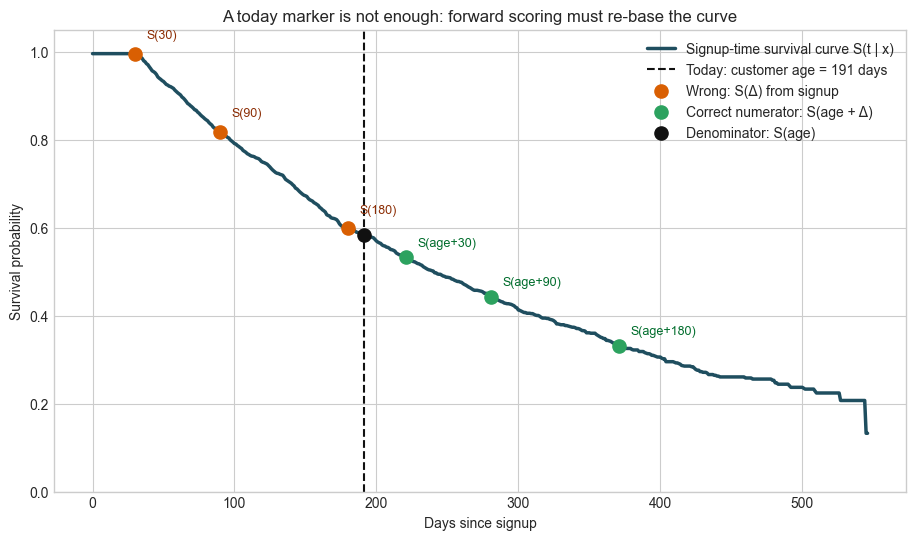

In [6]:
candidate_pool = scoring_raw[scoring_raw["age_today"].between(170, 260)].copy()
candidate_pool["distance_from_teaching_target"] = (candidate_pool["risk_percentile"] - 0.80).abs()
example_idx = candidate_pool.sort_values("distance_from_teaching_target").index[0]

example = scoring_raw.loc[example_idx]
example_X = X_score.loc[[example_idx]]
example_age = int(example["age_today"])

example_summary = example[
    [
        "customer_id",
        "signup_date",
        "plan",
        "acquisition_channel",
        "region",
        "age_today",
        "onboarding_score_30",
        "first_30_logins",
        "key_feature_events_30",
        "support_tickets_30",
        "payment_failures_30",
        "risk_percentile",
    ]
].to_frame("value")

display(example_summary)

max_time = int(model_raw["duration_days_since_signup"].max())
full_times = np.arange(0, max_time + 1)
full_survival = cph.predict_survival_function(example_X, times=full_times).iloc[:, 0]

naive = naive_signup_survival(cph, example_X, HORIZONS)
forward = forward_survival_from_age(cph, example_X, example_age, HORIZONS)
survival_at_age = float(cph.predict_survival_function(example_X, times=[example_age]).iloc[0, 0])
future_curve_points = cph.predict_survival_function(example_X, times=example_age + HORIZONS).iloc[:, 0]

comparison = pd.DataFrame(
    {
        "horizon_days": HORIZONS,
        "wrong_S_horizon_from_signup": naive.values,
        "correct_forward_survival_from_today": forward.values,
        "correct_forward_churn_risk_from_today": 1 - forward.values,
    }
)

display(
    comparison.style.format(
        {
            "wrong_S_horizon_from_signup": "{:.1%}",
            "correct_forward_survival_from_today": "{:.1%}",
            "correct_forward_churn_risk_from_today": "{:.1%}",
        }
    )
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(full_survival.index, full_survival.values, color="#1f4e5f", linewidth=2.5, label="Signup-time survival curve S(t | x)")
ax.axvline(example_age, color="#111111", linestyle="--", linewidth=1.5, label=f"Today: customer age = {example_age} days")
ax.scatter(HORIZONS, naive.values, color="#d95f02", s=90, zorder=3, label="Wrong: S(Δ) from signup")
ax.scatter(example_age + HORIZONS, future_curve_points.values, color="#2ca25f", s=90, zorder=3, label="Correct numerator: S(age + Δ)")
ax.scatter([example_age], [survival_at_age], color="#111111", s=90, zorder=4, label="Denominator: S(age)")

for h, y in zip(HORIZONS, naive.values):
    ax.annotate(f"S({h})", xy=(h, y), xytext=(h + 8, y + 0.035), fontsize=9, color="#8c2d04")

for h, y in zip(HORIZONS, future_curve_points.values):
    ax.annotate(f"S(age+{h})", xy=(example_age + h, y), xytext=(example_age + h + 8, y + 0.025), fontsize=9, color="#006d2c")

ax.set_title("A today marker is not enough: forward scoring must re-base the curve")
ax.set_xlabel("Days since signup")
ax.set_ylabel("Survival probability")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
plt.show()

## 6. Rebase the curve so the x-axis starts today

The previous plot showed the full lifetime curve because that is where the mistake is visible.

A client page usually wants the re-based curve below:

- x-axis: days from today;
- y-axis: probability of still being active, given active today;
- value at day 0: exactly 100% because this customer is alive at the scoring date.

This is the curve the Aegis kernel should expose to planning tools.

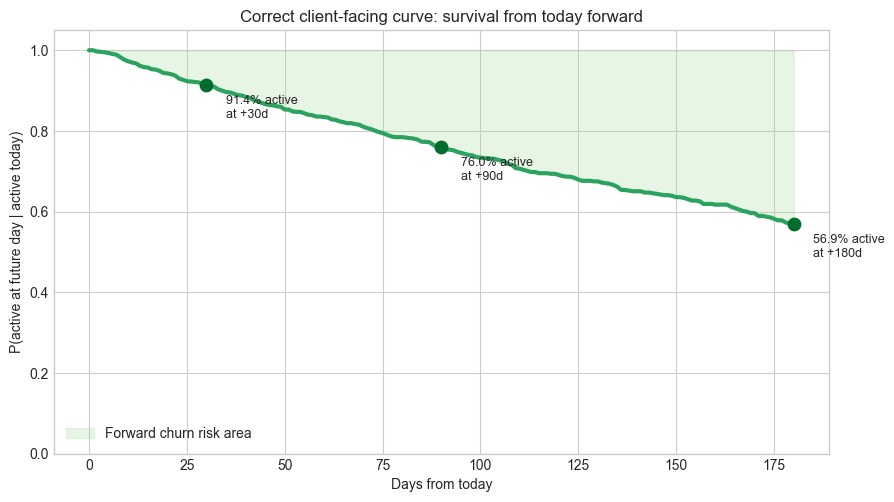

In [7]:
delta_grid = np.arange(0, 181)
conditioned_curve_times = example_age + delta_grid
conditioned_raw = cph.predict_survival_function(example_X, times=conditioned_curve_times).iloc[:, 0]
conditioned_curve = conditioned_raw / conditioned_raw.iloc[0]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(delta_grid, conditioned_curve.values, color="#2ca25f", linewidth=3)
ax.fill_between(delta_grid, conditioned_curve.values, 1, color="#a1d99b", alpha=0.25, label="Forward churn risk area")

for h in HORIZONS:
    y = float(conditioned_curve.loc[example_age + h])
    ax.scatter([h], [y], color="#006d2c", s=80, zorder=3)
    ax.annotate(f"{y:.1%} active\nat +{h}d", xy=(h, y), xytext=(h + 5, y - 0.08), fontsize=9)

ax.set_title("Correct client-facing curve: survival from today forward")
ax.set_xlabel("Days from today")
ax.set_ylabel("P(active at future day | active today)")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")
plt.show()

## 7. lifelines can do the same conditioning for you

We implemented the ratio manually because it is the concept you must understand.

In `lifelines`, `predict_survival_function` also has a `conditional_after` argument. For a signup-time model, that argument says: "this person has already survived this many days; return the remaining survival curve from that point."

The two methods should match.

In [8]:
manual_forward = forward_survival_from_age(cph, example_X, example_age, HORIZONS)

lifelines_forward = cph.predict_survival_function(
    example_X,
    times=HORIZONS,
    conditional_after=[example_age],
).iloc[:, 0]

implementation_check = pd.DataFrame(
    {
        "horizon_days": HORIZONS,
        "manual_ratio": manual_forward.values,
        "lifelines_conditional_after": lifelines_forward.values,
        "absolute_difference": np.abs(manual_forward.values - lifelines_forward.values),
    }
)

display(
    implementation_check.style.format(
        {
            "manual_ratio": "{:.6f}",
            "lifelines_conditional_after": "{:.6f}",
            "absolute_difference": "{:.2e}",
        }
    )
)

,horizon_days,manual_ratio,lifelines_conditional_after,absolute_difference
0,30,0.913796,0.913796,1.11e-16
1,90,0.760111,0.760111,0.00e+00
2,180,0.569206,0.569206,1.11e-16


## 8. Score everyone alive today

Now we turn the idea into a scorecard.

For every active customer, we compute both:

- the **wrong signup-time values**, `S(30)`, `S(90)`, `S(180)`;
- the **right forward-looking values**, `S(age + Δ) / S(age)`.

The mistake is not always in the same direction for every customer because survival curves can have different shapes across time. But the semantic error is always the same: `S(Δ)` answers a lifetime-age question, not a today-forward question.

In [9]:
score_rows = []

for idx, row in scoring_raw.iterrows():
    x_row = X_score.loc[[idx]]
    age = int(row["age_today"])
    naive_values = naive_signup_survival(cph, x_row, HORIZONS)
    forward_values = forward_survival_from_age(cph, x_row, age, HORIZONS)

    record = {
        "customer_id": row["customer_id"],
        "signup_date": row["signup_date"],
        "plan": row["plan"],
        "age_today": age,
        "risk_percentile": row["risk_percentile"],
    }

    for h in HORIZONS:
        record[f"wrong_S_{h}d_from_signup"] = naive_values.loc[h]
        record[f"S_{h}d_from_today"] = forward_values.loc[h]
        record[f"churn_risk_{h}d_from_today"] = 1 - forward_values.loc[h]

    score_rows.append(record)

scorecard = pd.DataFrame(score_rows)

comparison_summary = pd.DataFrame(
    {
        "mean_wrong_signup_survival": [scorecard[f"wrong_S_{h}d_from_signup"].mean() for h in HORIZONS],
        "mean_correct_forward_survival": [scorecard[f"S_{h}d_from_today"].mean() for h in HORIZONS],
        "mean_correct_forward_churn_risk": [scorecard[f"churn_risk_{h}d_from_today"].mean() for h in HORIZONS],
    },
    index=[f"{h} days" for h in HORIZONS],
)

display(comparison_summary.style.format("{:.1%}"))

display(
    scorecard[
        [
            "customer_id",
            "plan",
            "age_today",
            "risk_percentile",
            "wrong_S_90d_from_signup",
            "S_90d_from_today",
            "churn_risk_90d_from_today",
            "S_180d_from_today",
            "churn_risk_180d_from_today",
        ]
    ]
    .sort_values("churn_risk_180d_from_today", ascending=False)
    .head(10)
    .style.format(
        {
            "risk_percentile": "{:.1%}",
            "wrong_S_90d_from_signup": "{:.1%}",
            "S_90d_from_today": "{:.1%}",
            "churn_risk_90d_from_today": "{:.1%}",
            "S_180d_from_today": "{:.1%}",
            "churn_risk_180d_from_today": "{:.1%}",
        }
    )
)

,mean_wrong_signup_survival,mean_correct_forward_survival,mean_correct_forward_churn_risk
30 days,99.7%,94.0%,6.0%
90 days,88.3%,83.8%,16.2%
180 days,74.3%,72.4%,27.6%


,customer_id,plan,age_today,risk_percentile,wrong_S_90d_from_signup,S_90d_from_today,churn_risk_90d_from_today,S_180d_from_today,churn_risk_180d_from_today
1356,R02224,Starter,61,100.0%,28.8%,15.9%,84.1%,2.5%,97.5%
30,R00047,Starter,130,99.9%,38.7%,24.1%,75.9%,6.5%,93.5%
718,R01174,Starter,188,99.9%,44.0%,33.7%,66.3%,10.4%,89.6%
605,R00994,Starter,96,99.8%,45.4%,29.7%,70.3%,10.4%,89.6%
292,R00489,Starter,134,99.8%,46.2%,30.3%,69.7%,10.6%,89.4%
1449,R02368,Starter,43,99.6%,50.3%,38.3%,61.7%,13.5%,86.5%
67,R00104,Starter,83,99.7%,50.2%,34.9%,65.1%,13.9%,86.1%
1095,R01777,Starter,195,99.6%,51.3%,39.0%,61.0%,14.9%,85.1%
754,R01229,Starter,145,99.5%,53.5%,39.5%,60.5%,17.2%,82.8%
766,R01250,Starter,203,99.4%,53.7%,42.4%,57.6%,17.7%,82.3%


## 9. Visual audit: where the naive answer drifts

A useful QA plot for production scoring is the difference between the correct and incorrect answer.

Here we plot:

\[
S(age + 180) / S(age) - S(180)
\]

against customer age today.

If a dashboard uses `S(180)` for everyone, it is silently ignoring the fact that some customers are 40 days old and others are 350 days old. The bigger and more structured the difference, the more dangerous the shortcut.

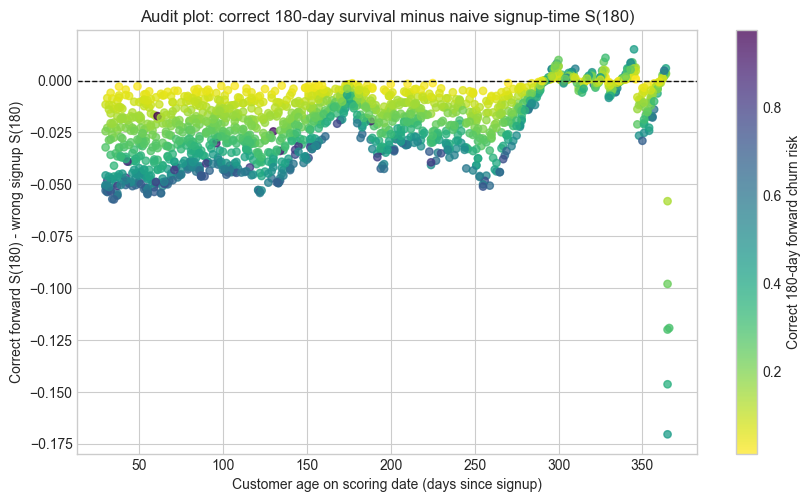

Customers where the naive 180-day answer differs by at least 5 percentage points:
3.0%


,customer_id,age_today,wrong_S_180d_from_signup,S_180d_from_today,delta_correct_minus_wrong_180d,churn_risk_180d_from_today
1064,R01724,365,73.0%,55.9%,-17.1%,44.1%
916,R01481,365,78.3%,63.6%,-14.6%,36.4%
662,R01088,365,83.1%,71.1%,-12.0%,28.9%
337,R00564,366,83.0%,71.1%,-11.9%,28.9%
858,R01391,365,86.8%,77.0%,-9.8%,23.0%
691,R01135,365,92.6%,86.8%,-5.8%,13.2%
758,R01235,35,37.0%,31.3%,-5.7%,68.7%
813,R01316,34,38.9%,33.2%,-5.7%,66.8%


In [10]:
scorecard["delta_correct_minus_wrong_180d"] = scorecard["S_180d_from_today"] - scorecard["wrong_S_180d_from_signup"]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(
    scorecard["age_today"],
    scorecard["delta_correct_minus_wrong_180d"],
    c=scorecard["churn_risk_180d_from_today"],
    cmap="viridis_r",
    alpha=0.75,
    s=28,
)
ax.axhline(0, color="#111111", linestyle="--", linewidth=1)
ax.set_title("Audit plot: correct 180-day survival minus naive signup-time S(180)")
ax.set_xlabel("Customer age on scoring date (days since signup)")
ax.set_ylabel("Correct forward S(180) - wrong signup S(180)")
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label("Correct 180-day forward churn risk")
plt.show()

scorecard["absolute_delta_180d"] = scorecard["delta_correct_minus_wrong_180d"].abs()

print("Customers where the naive 180-day answer differs by at least 5 percentage points:")
print(f"{(scorecard['absolute_delta_180d'] >= 0.05).mean():.1%}")

display(
    scorecard.sort_values("absolute_delta_180d", ascending=False)[
        [
            "customer_id",
            "age_today",
            "wrong_S_180d_from_signup",
            "S_180d_from_today",
            "delta_correct_minus_wrong_180d",
            "churn_risk_180d_from_today",
        ]
    ]
    .head(8)
    .style.format(
        {
            "wrong_S_180d_from_signup": "{:.1%}",
            "S_180d_from_today": "{:.1%}",
            "delta_correct_minus_wrong_180d": "{:+.1%}",
            "churn_risk_180d_from_today": "{:.1%}",
        }
    )
)

## 10. Turn the forward curve into planning tiers

Once the probabilities are correctly conditioned, you can safely build a business rule on top.

Example policy:

- **Act now:** 90-day forward churn risk is at least 35%.
- **Watchlist:** 180-day forward churn risk is at least 35%, but 90-day risk is below 35%.
- **Healthy / nurture:** neither threshold is hit.

The thresholds are not universal. The important part is that every tier is based on a probability that means: "from the scoring date forward."

In [11]:
conditions = [
    scorecard["churn_risk_90d_from_today"] >= 0.35,
    scorecard["churn_risk_180d_from_today"] >= 0.35,
]
choices = ["Act now", "Watchlist"]
scorecard["planning_tier"] = np.select(conditions, choices, default="Healthy / nurture")

tier_summary = (
    scorecard.groupby("planning_tier", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_age_days=("age_today", "mean"),
        avg_90d_churn_risk=("churn_risk_90d_from_today", "mean"),
        avg_180d_churn_risk=("churn_risk_180d_from_today", "mean"),
        avg_wrong_180d_survival=("wrong_S_180d_from_signup", "mean"),
        avg_correct_180d_survival=("S_180d_from_today", "mean"),
    )
    .sort_values("avg_180d_churn_risk", ascending=False)
)

tier_summary["customer_share"] = tier_summary["customers"] / tier_summary["customers"].sum()

display(
    tier_summary.style.format(
        {
            "avg_age_days": "{:.0f}",
            "avg_90d_churn_risk": "{:.1%}",
            "avg_180d_churn_risk": "{:.1%}",
            "avg_wrong_180d_survival": "{:.1%}",
            "avg_correct_180d_survival": "{:.1%}",
            "customer_share": "{:.1%}",
        }
    )
)

,customers,avg_age_days,avg_90d_churn_risk,avg_180d_churn_risk,avg_wrong_180d_survival,avg_correct_180d_survival,customer_share
planning_tier,,,,,,,
Act now,137,134,44.9%,68.0%,36.0%,32.0%,8.5%
Watchlist,334,169,26.4%,44.9%,58.3%,55.1%,20.8%
Healthy / nurture,1136,186,9.7%,17.7%,83.7%,82.3%,70.7%


## 11. The same rule works for a Kaplan-Meier fallback

Not every customer can be scored by a feature-rich model. Maybe they are missing covariates, maybe they sit outside model eligibility, or maybe you want a simple baseline.

A Kaplan-Meier curve is still a survival curve, so the same conditioning rule applies:

\[
S_{KM}(age + \Delta) / S_{KM}(age)
\]

If a fallback scorecard gives out-of-model customers `S_KM(90)` from signup, it repeats the same semantic mistake.

In [12]:
kmf = KaplanMeierFitter()
kmf.fit(model_raw["duration_days_since_signup"], event_observed=model_raw["churn_observed"])


def km_survival_at(times: np.ndarray) -> np.ndarray:
    return kmf.survival_function_at_times(times).to_numpy(dtype=float)


example_km_times = np.r_[example_age, example_age + HORIZONS]
example_km_values = km_survival_at(example_km_times)
km_forward = example_km_values[1:] / example_km_values[0]
km_wrong = km_survival_at(HORIZONS)

km_comparison = pd.DataFrame(
    {
        "horizon_days": HORIZONS,
        "wrong_KM_S_horizon_from_signup": km_wrong,
        "correct_KM_forward_survival_from_today": km_forward,
        "correct_KM_forward_churn_risk_from_today": 1 - km_forward,
    }
)

display(
    km_comparison.style.format(
        {
            "wrong_KM_S_horizon_from_signup": "{:.1%}",
            "correct_KM_forward_survival_from_today": "{:.1%}",
            "correct_KM_forward_churn_risk_from_today": "{:.1%}",
        }
    )
)

,horizon_days,wrong_KM_S_horizon_from_signup,correct_KM_forward_survival_from_today,correct_KM_forward_churn_risk_from_today
0,30,100.0%,94.7%,5.3%
1,90,85.1%,85.2%,14.8%
2,180,69.0%,73.0%,27.0%


## 12. Production rule of thumb for an Aegis-style scoring kernel

A scoring kernel should make the time origin impossible to misunderstand.

A safe contract looks like this:

```python
score_customer(
    customer_features,
    as_of_date="2025-01-01",
    horizons=[30, 90, 180],
) -> {
    "S_30d_from_as_of": ...,
    "S_90d_from_as_of": ...,
    "S_180d_from_as_of": ...,
    "churn_risk_90d_from_as_of": ...,
    "time_origin": "as_of_date",
    "conditioning": "customer_alive_at_as_of_date",
}
```

Checklist:

- If your model clock starts at signup, score future horizons with `S(age + Δ) / S(age)` or a library equivalent such as `conditional_after`.
- If your model clock starts at a landmark, `S(Δ)` is already forward-looking because the dataset was rebuilt around that landmark.
- If a dashboard shows a vertical "today" line but reports `S(Δ)` from signup, the visualization is honest-looking but the probability is not the client question.
- Every exported probability name should include the time origin: `from_signup`, `from_landmark`, or `from_as_of`.

This is the difference between a nice survival chart and a true planning probability.